In [14]:
import os
os.makedirs("outputs", exist_ok=True)
# Cell 1 — Load all tables + fix dates + build master
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
sns.set_theme(style="whitegrid")

DATA = r"C:\Users\akki7\OneDrive\Desktop\ecommerce-funnel\data"

# Load all 5 tables
orders    = pd.read_csv(f"{DATA}/olist_orders_dataset.csv")
payments  = pd.read_csv(f"{DATA}/olist_order_payments_dataset.csv")
customers = pd.read_csv(f"{DATA}/olist_customers_dataset.csv")
items     = pd.read_csv(f"{DATA}/olist_order_items_dataset.csv")
products  = pd.read_csv(f"{DATA}/olist_products_dataset.csv")

# Fix dates
orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"]
)

# Step 1: join items + products to get category name
items_with_cat = items.merge(
    products[["product_id", "product_category_name"]],
    on="product_id",
    how="left"
)

# Step 2: collapse to one row per order
item_agg = items_with_cat.groupby("order_id").agg(
    item_count   = ("order_item_id",          "count"),
    item_revenue = ("price",                   "sum"),
    category     = ("product_category_name",   "first")
).reset_index()

# Step 3: collapse payments to one row per order
pay = payments.groupby("order_id")["payment_value"].sum().reset_index()
pay.columns = ["order_id", "total_payment"]

# Step 4: build master — chain all merges
master = (orders
    .merge(pay,       on="order_id",    how="left")
    .merge(item_agg,  on="order_id",    how="left")
    .merge(customers, on="customer_id", how="left")
)

# Step 5: add helper columns
master["month"]       = master["order_purchase_timestamp"].dt.to_period("M")
master["month_num"]   = master["order_purchase_timestamp"].dt.month
master["year"]        = master["order_purchase_timestamp"].dt.year
master["is_cancelled"] = master["order_status"] == "canceled"
master["is_lost"]      = master["order_status"].isin(
    ["canceled", "unavailable"]
)

print(f"✓ Master table: {len(master):,} rows × {len(master.columns)} columns")
print(f"✓ Categories found: {master['category'].nunique()} unique")
print(f"✓ States found:     {master['customer_state'].nunique()} unique")
print(f"✓ Sample categories: {master['category'].dropna().unique()[:5].tolist()}")

✓ Master table: 99,441 rows × 21 columns
✓ Categories found: 73 unique
✓ States found:     27 unique
✓ Sample categories: ['utilidades_domesticas', 'perfumaria', 'automotivo', 'pet_shop', 'papelaria']


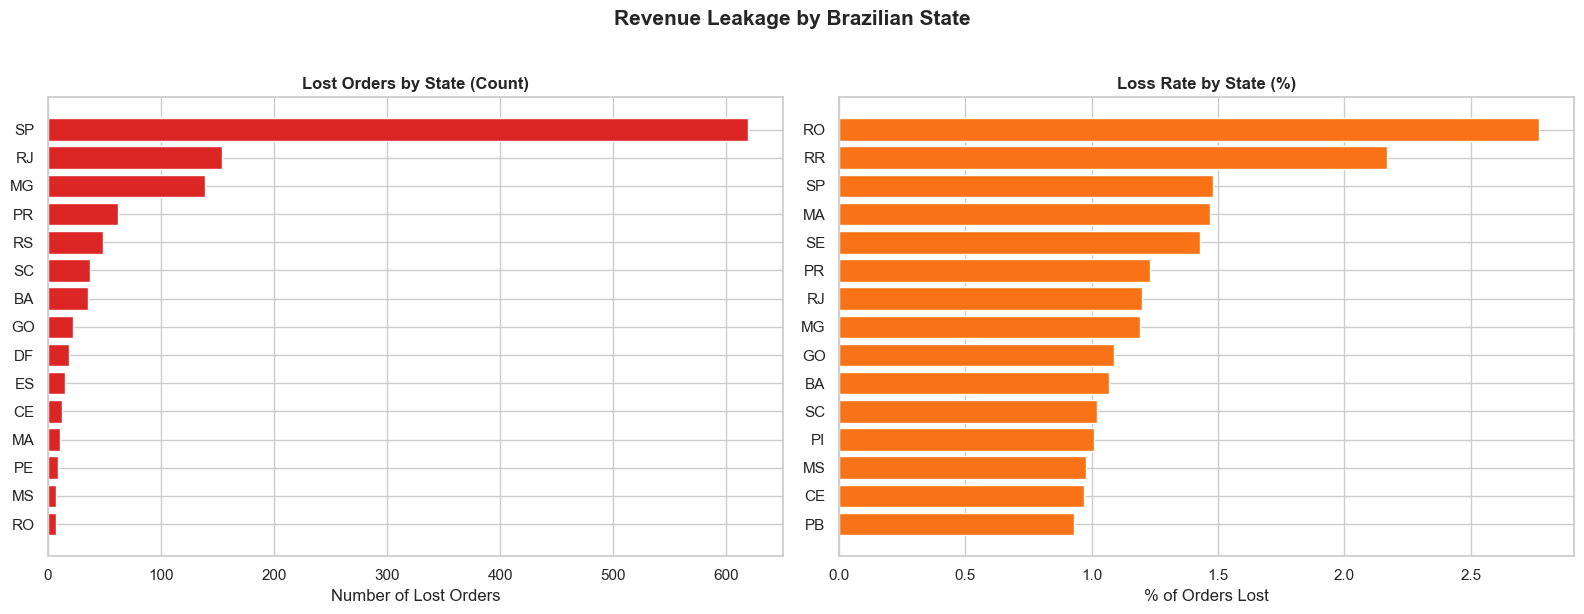


Top 5 states by lost orders:
customer_state  total_orders  lost_orders  loss_rate
            SP         41746          619       1.48
            RJ         12852          154       1.20
            MG         11635          139       1.19
            PR          5045           62       1.23
            RS          5466           49       0.90


In [15]:
# Cell 2 — Which states have the most lost orders?
state_analysis = master.groupby("customer_state").agg(
    total_orders   = ("order_id",    "count"),
    lost_orders    = ("is_lost",     "sum"),
    total_revenue  = ("total_payment","sum")
).reset_index()

state_analysis["loss_rate"] = (
    state_analysis["lost_orders"] /
    state_analysis["total_orders"] * 100
).round(2)

state_analysis["est_lost_revenue"] = (
    state_analysis["lost_orders"] *
    (master["total_payment"].mean())
).round(2)

# Chart — top 15 states by lost orders
top15 = state_analysis.nlargest(15, "lost_orders")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: raw count of lost orders
axes[0].barh(top15["customer_state"], top15["lost_orders"],
             color="#dc2626", edgecolor="white")
axes[0].invert_yaxis()
axes[0].set_title("Lost Orders by State (Count)", fontweight="bold")
axes[0].set_xlabel("Number of Lost Orders")

# Right: loss rate %
top15_rate = state_analysis.nlargest(15, "loss_rate")
axes[1].barh(top15_rate["customer_state"], top15_rate["loss_rate"],
             color="#f97316", edgecolor="white")
axes[1].invert_yaxis()
axes[1].set_title("Loss Rate by State (%)", fontweight="bold")
axes[1].set_xlabel("% of Orders Lost")

plt.suptitle("Revenue Leakage by Brazilian State",
             fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("outputs/05_leakage_by_state.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nTop 5 states by lost orders:")
print(state_analysis.nlargest(5, "lost_orders")[[
    "customer_state","total_orders","lost_orders","loss_rate"
]].to_string(index=False))

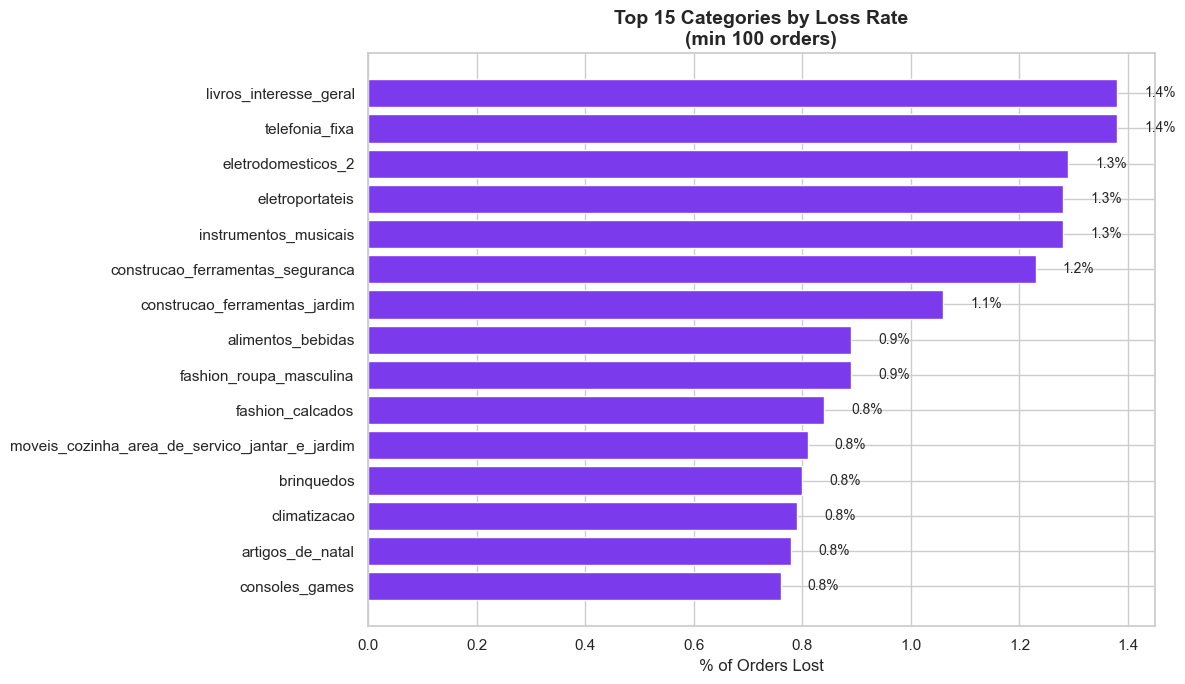

In [16]:
# Cell 3 — Which product categories lose the most orders?
cat_analysis = master.groupby("category").agg(
    total_orders = ("order_id", "count"),
    lost_orders  = ("is_lost",  "sum"),
).reset_index()

cat_analysis["loss_rate"] = (
    cat_analysis["lost_orders"] /
    cat_analysis["total_orders"] * 100
).round(2)

# Only show categories with enough orders to be meaningful
cat_filtered = cat_analysis[cat_analysis["total_orders"] >= 100]
top_cat = cat_filtered.nlargest(15, "loss_rate")

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(top_cat["category"], top_cat["loss_rate"],
               color="#7c3aed", edgecolor="white")

for bar in bars:
    ax.text(bar.get_width() + 0.05,
            bar.get_y() + bar.get_height() / 2,
            f"{bar.get_width():.1f}%",
            va="center", fontsize=10)

ax.invert_yaxis()
ax.set_title("Top 15 Categories by Loss Rate\n(min 100 orders)",
             fontsize=14, fontweight="bold")
ax.set_xlabel("% of Orders Lost")
plt.tight_layout()
plt.savefig("outputs/06_leakage_by_category.png", dpi=150, bbox_inches="tight")
plt.show()

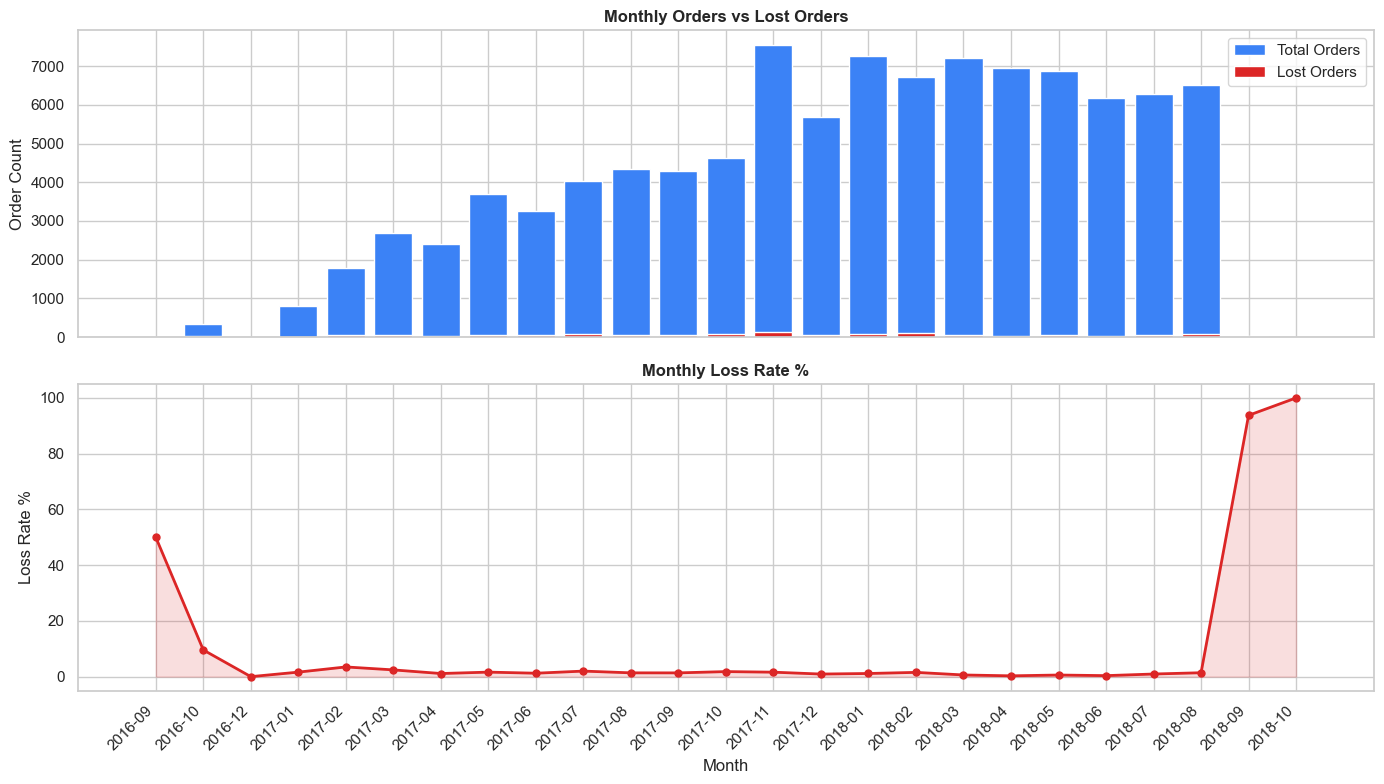

Top 3 worst months by loss rate:
month_str  total_orders  lost_orders  loss_rate
  2018-10             4            4     100.00
  2018-09            16           15      93.75
  2016-09             4            2      50.00


In [17]:
# Cell 4 — Do cancellations spike in certain months?
monthly = master.groupby("month").agg(
    total_orders = ("order_id", "count"),
    lost_orders  = ("is_lost",  "sum"),
).reset_index()

monthly["loss_rate"]  = (monthly["lost_orders"] / monthly["total_orders"] * 100).round(2)
monthly["month_str"] = monthly["month"].astype(str)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Top: total orders per month
ax1.bar(monthly["month_str"], monthly["total_orders"],
        color="#3b82f6", edgecolor="white", label="Total Orders")
ax1.bar(monthly["month_str"], monthly["lost_orders"],
        color="#dc2626", edgecolor="white", label="Lost Orders")
ax1.set_title("Monthly Orders vs Lost Orders", fontweight="bold")
ax1.set_ylabel("Order Count")
ax1.legend()

# Bottom: loss rate % over time
ax2.plot(monthly["month_str"], monthly["loss_rate"],
         color="#dc2626", marker="o", linewidth=2, markersize=5)
ax2.fill_between(monthly["month_str"], monthly["loss_rate"],
                 alpha=0.15, color="#dc2626")
ax2.set_title("Monthly Loss Rate %", fontweight="bold")
ax2.set_ylabel("Loss Rate %")
ax2.set_xlabel("Month")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("outputs/07_leakage_over_time.png", dpi=150, bbox_inches="tight")
plt.show()

worst_month = monthly.nlargest(3, "loss_rate")[
    ["month_str", "total_orders", "lost_orders", "loss_rate"]
]
print("Top 3 worst months by loss rate:")
print(worst_month.to_string(index=False))

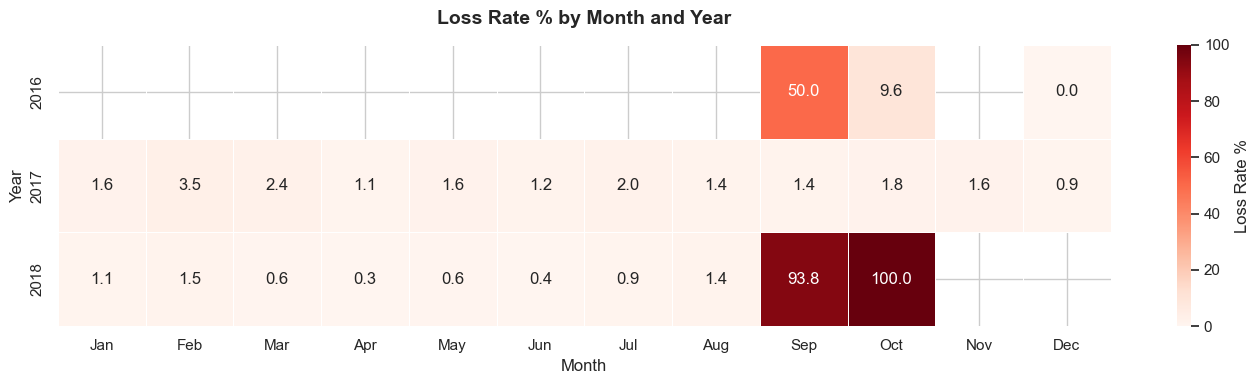

In [18]:
# Cell 5 — Heatmap: loss rate by month number × year
heat_data = master.groupby(["year", "month_num"]).agg(
    total  = ("order_id", "count"),
    lost   = ("is_lost",  "sum")
).reset_index()
heat_data["loss_rate"] = (heat_data["lost"] / heat_data["total"] * 100).round(2)

# Pivot: rows = year, columns = month, values = loss_rate
pivot = heat_data.pivot(index="year", columns="month_num", values="loss_rate")
pivot.columns = ["Jan","Feb","Mar","Apr","May","Jun",
                 "Jul","Aug","Sep","Oct","Nov","Dec"]

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="Reds",
            linewidths=0.5, ax=ax, cbar_kws={"label":"Loss Rate %"})
ax.set_title("Loss Rate % by Month and Year",
             fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Month")
ax.set_ylabel("Year")
plt.tight_layout()
plt.savefig("outputs/08_heatmap_loss_rate.png", dpi=150, bbox_inches="tight")
plt.show()

In [12]:
# Cell 6 — Print your complete project findings
avg_val       = master["total_payment"].mean()
total_lost    = master["is_lost"].sum()
total_orders  = len(master)
total_revenue = master["total_payment"].sum()
est_leakage   = total_lost * avg_val
worst_state   = state_analysis.nlargest(1, "lost_orders")["customer_state"].values[0]
worst_cat     = cat_filtered.nlargest(1, "loss_rate")["category"].values[0]

print("=" * 55)
print("  OLIST E-COMMERCE — REVENUE LEAKAGE ANALYSIS")
print("=" * 55)
print(f"  Period:            Sep 2016 – Oct 2018")
print(f"  Total orders:      {total_orders:,}")
print(f"  Total revenue:     R${total_revenue:,.0f}")
print(f"  Avg order value:   R${avg_val:.2f}")
print("—" * 55)
print(f"  Lost orders:       {total_lost:,}  ({total_lost/total_orders*100:.2f}%)")
print(f"  Est. leakage:      R${est_leakage:,.0f}")
print(f"  Cancelled:         625  (77.4% had payment approved)")
print(f"  Unavailable:       609  (seller inventory failure)")
print("—" * 55)
print(f"  Worst state:       {worst_state} (most lost orders)")
print(f"  Worst category:    {worst_cat} (highest loss rate)")
print("—" * 55)
print("  RECOMMENDATIONS:")
print("  1. Audit sellers in high-loss categories")
print("  2. Require inventory verification before listing")
print("  3. Flag sellers with >2% cancellation rate")
print("  4. Auto-cancel unapproved orders after 24hrs")
print("=" * 55)

  OLIST E-COMMERCE — REVENUE LEAKAGE ANALYSIS
  Period:            Sep 2016 – Oct 2018
  Total orders:      99,441
  Total revenue:     R$16,008,872
  Avg order value:   R$160.99
———————————————————————————————————————————————————————
  Lost orders:       1,234  (1.24%)
  Est. leakage:      R$198,662
  Cancelled:         625  (77.4% had payment approved)
  Unavailable:       609  (seller inventory failure)
———————————————————————————————————————————————————————
  Worst state:       SP (most lost orders)
  Worst category:    livros_interesse_geral (highest loss rate)
———————————————————————————————————————————————————————
  RECOMMENDATIONS:
  1. Audit sellers in high-loss categories
  2. Require inventory verification before listing
  3. Flag sellers with >2% cancellation rate
  4. Auto-cancel unapproved orders after 24hrs


In [13]:
state_analysis.nlargest(5,"loss_rate")[["customer_state","total_orders","loss_rate"]]

,customer_state,total_orders,loss_rate
20,RO,253,2.77
21,RR,46,2.17
25,SP,41746,1.48
9,MA,747,1.47
24,SE,350,1.43
